# Détection de SMS Spam — Classification NLP

Classifier des SMS en spam ou ham (légitime) en utilisant
le traitement du langage naturel (NLP) et le machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 1. Nettoyage initial du dataset

On garde uniquement les colonnes utiles et on les renomme.

In [2]:
# Garder seulement les 2 colonnes utiles
df = df[['v1', 'v2']]

# Renommer les colonnes
df.columns = ['label', 'message']

# Vérification
print("Dimensions :", df.shape)
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nAperçu :")
df.head()

Dimensions : (5572, 2)

Valeurs manquantes :
label      0
message    0
dtype: int64

Aperçu :


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Exploration des données (EDA)

On explore la distribution des classes et les caractéristiques des messages.

Distribution des classes :
label
ham     4825
spam     747
Name: count, dtype: int64

En pourcentage :
label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


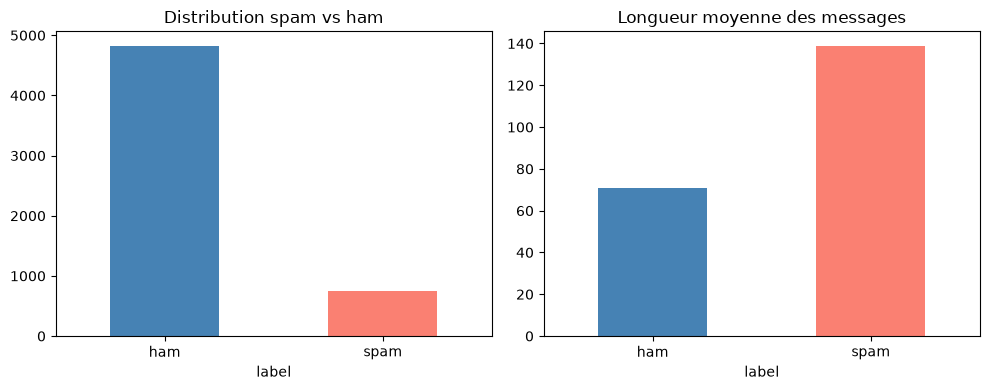

In [3]:
# Distribution spam vs ham
print("Distribution des classes :")
print(df['label'].value_counts())
print()
print("En pourcentage :")
print(df['label'].value_counts(normalize=True).round(3) * 100)

# Visualisation
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribution spam vs ham')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['message_length'] = df['message'].apply(len)
df.groupby('label')['message_length'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Longueur moyenne des messages')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Nettoyage du texte

On prépare les messages pour le modèle :
- Minuscules
- Suppression de la ponctuation
- Suppression des stopwords (mots courants sans valeur prédictive: "the", "is", "at", "to", "a"...)

In [5]:
import nltk
import string
from nltk.corpus import stopwords

# Télécharger les stopwords
nltk.download('stopwords')

# Fonction de nettoyage
def nettoyer_texte(message):
    # Minuscules
    message = message.lower()
    # Supprimer la ponctuation
    message = ''.join([c for c in message if c not in string.punctuation])
    # Supprimer les stopwords
    mots = message.split()
    mots = [m for m in mots if m not in stopwords.words('english')]
    return ' '.join(mots)

# Appliquer le nettoyage
df['message_clean'] = df['message'].apply(nettoyer_texte)

# Comparaison avant/après
print("AVANT :", df['message'][2])
print()
print("APRÈS :", df['message_clean'][2])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cynth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


AVANT : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

APRÈS : free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s


## 4. Vectorisation TF-IDF

On convertit le texte en chiffres. TF-IDF mesure l'importance
de chaque mot dans un message par rapport à tout le dataset.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Encoder le label : ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['message_clean'], df['label_encoded'],
    test_size=0.2, random_state=42
)

# Vectorisation TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Taille train :", X_train_tfidf.shape)
print("Taille test  :", X_test_tfidf.shape)

Taille train : (4457, 3000)
Taille test  : (1115, 3000)


## 5. Entraînement du modèle — Naive Bayes

Naive Bayes est le classifieur standard pour la classification
de texte : rapide, simple et très efficace sur des données NLP.

In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Entraînement
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Prédictions
y_pred = model.predict(X_test_tfidf)

# Évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print()
print("Rapport complet :")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy : 0.9766816143497757

Rapport complet :
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       965
        Spam       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 6. Visualisation des mots les plus fréquents

On explore les mots les plus caractéristiques des spams et des ham.

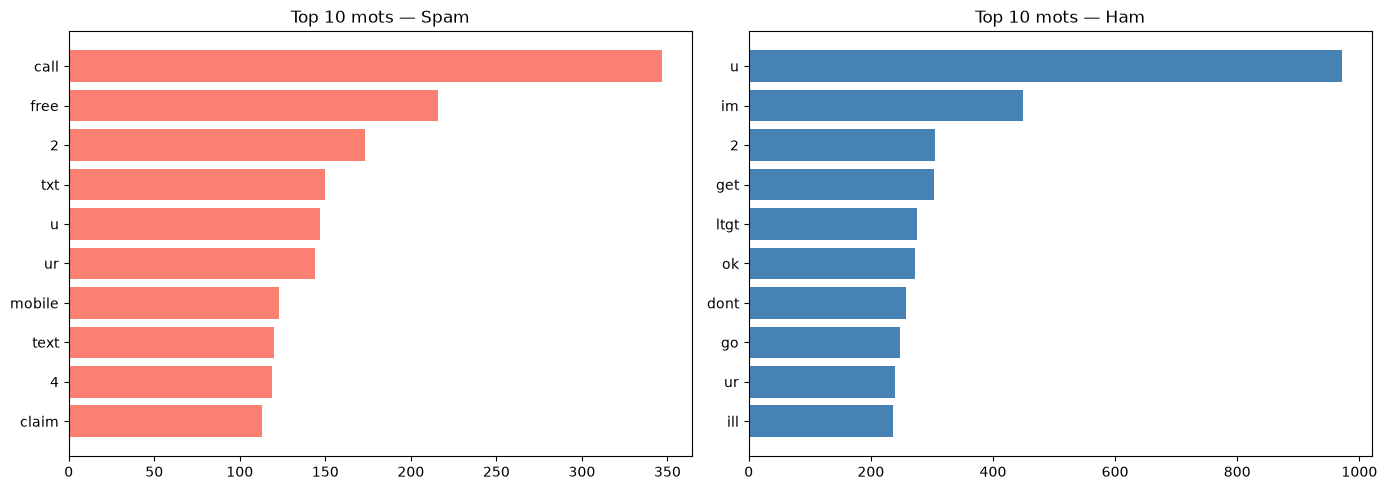

In [8]:
from collections import Counter

# Séparer les messages spam et ham
spam_messages = ' '.join(df[df['label'] == 'spam']['message_clean'])
ham_messages = ' '.join(df[df['label'] == 'ham']['message_clean'])

# Compter les mots
spam_words = Counter(spam_messages.split()).most_common(10)
ham_words = Counter(ham_messages.split()).most_common(10)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam
words, counts = zip(*spam_words)
axes[0].barh(words, counts, color='salmon')
axes[0].set_title('Top 10 mots — Spam')
axes[0].invert_yaxis()

# Ham
words, counts = zip(*ham_words)
axes[1].barh(words, counts, color='steelblue')
axes[1].set_title('Top 10 mots — Ham')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Test du modèle sur des SMS personnalisés

On teste le modèle sur des messages inventés pour vérifier
qu'il généralise bien.

In [10]:
# Fonction de prédiction sur un nouveau SMS
def predire_sms(message):
    message_clean = nettoyer_texte(message)
    message_tfidf = tfidf.transform([message_clean])
    prediction = model.predict(message_tfidf)[0]
    probabilite = model.predict_proba(message_tfidf)[0]
    
    label = 'SPAM' if prediction == 1 else 'HAM'
    print(f"Message  : {message}")
    print(f"Résultat : {label}")
    print(f"Probabilité ham  : {probabilite[0]:.2%}")
    print(f"Probabilité spam : {probabilite[1]:.2%}")
    print("-" * 50)

# Tests
predire_sms("Congratulations! You won a free iPhone. Click here to claim your prize now!")
predire_sms("Hey, are we still meeting for lunch tomorrow?")
predire_sms("URGENT: Your account has been compromised. Call us free on 0800123456 now!")
predire_sms("Can you pick up some milk on your way home?")
predire_sms("Win cash prizes worth $1000! Text WIN to 12345 now!")

Message  : Congratulations! You won a free iPhone. Click here to claim your prize now!
Résultat : SPAM
Probabilité ham  : 3.63%
Probabilité spam : 96.37%
--------------------------------------------------
Message  : Hey, are we still meeting for lunch tomorrow?
Résultat : HAM
Probabilité ham  : 99.79%
Probabilité spam : 0.21%
--------------------------------------------------
Message  : URGENT: Your account has been compromised. Call us free on 0800123456 now!
Résultat : SPAM
Probabilité ham  : 43.13%
Probabilité spam : 56.87%
--------------------------------------------------
Message  : Can you pick up some milk on your way home?
Résultat : HAM
Probabilité ham  : 99.01%
Probabilité spam : 0.99%
--------------------------------------------------
Message  : Win cash prizes worth $1000! Text WIN to 12345 now!
Résultat : SPAM
Probabilité ham  : 6.51%
Probabilité spam : 93.49%
--------------------------------------------------


## 8. Sauvegarde du modèle

On sauvegarde le modèle et le vectoriseur TF-IDF ensemble
pour pouvoir les réutiliser sans réentraîner.

In [12]:
import joblib

# Sauvegarder le modèle et le vectoriseur
joblib.dump(model, 'naive_bayes_spam.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Modèle sauvegardé : naive_bayes_spam.pkl")
print("Vectoriseur sauvegardé : tfidf_vectorizer.pkl")

Modèle sauvegardé : naive_bayes_spam.pkl
Vectoriseur sauvegardé : tfidf_vectorizer.pkl
